# PQC Benchmark Analysis
This notebook provides a graphical analysis of benchmarking results for two web servers using different key exchange mechanisms: X25519 and X25519MLKEM768.

## Imports and environment setup
The following libraries are imported to support benchmark analysis and visualization. They are used for tabular data processing, numerical computation, file discovery, path handling, and chart generation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path
import glob
import math

## Configuration and data preparation
This section defines plotting settings, loads benchmark data, normalizes selected fields, and prepares shared variables used throughout the analysis.

In [2]:
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

CLASSIC_COLOR = '#2166ac'
HYBRID_COLOR  = '#d6604d'
ALPHA = 0.85

FIGURES_DIR = Path('results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

files = sorted(glob.glob('results/curl_benchmark/benchmark_*.csv'))
assert files, "No CSV files found in results/raw/"
print(f'Found {len(files)} CSV files')

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

df['endpoint'] = df['endpoint'].apply(
    lambda x: x.split('/', 1)[-1] if ':' in x else x
)

VARIANTS = df['variant'].unique().tolist()
assert 'classic' in VARIANTS and 'hybrid' in VARIANTS, \
    f"Expected 'classic' and 'hybrid' variants, got: {VARIANTS}"

ENDPOINT_ORDER = (
    df.groupby('endpoint')['size_bytes']
    .median()
    .sort_values()
    .index
    .tolist()
)

def make_label(ep, median_bytes):
    if median_bytes < 1024:
        return f'direct\n({int(median_bytes)} B)'
    elif median_bytes < 1024 * 1024:
        return f'{median_bytes/1024:.0f} KB'
    else:
        return f'{median_bytes/1024/1024:.0f} MB'

median_sizes = df.groupby('endpoint')['size_bytes'].median()
ENDPOINT_LABELS = {
    ep: make_label(ep, median_sizes[ep])
    for ep in ENDPOINT_ORDER
}

x = np.arange(len(ENDPOINT_ORDER))
width = 0.35

print(f'Variants:  {VARIANTS}')
print(f'Endpoints: {ENDPOINT_ORDER}')
print(f'Labels:    {ENDPOINT_LABELS}')
print(f'Total rows: {len(df)}')

Found 7 CSV files
Variants:  ['classic', 'hybrid']
Endpoints: ['api/direct', 'api/payload/1kb', 'api/payload/100kb', 'api/payload/1mb']
Labels:    {'api/direct': 'direct\n(2 B)', 'api/payload/1kb': '1 KB', 'api/payload/100kb': '100 KB', 'api/payload/1mb': '1 MB'}
Total rows: 11200


## TLS Handshake Latency Summary Statistics
This cell computes descriptive statistics for TLS handshake latency across endpoints and variants.  


In [3]:
def ci95_half(x):
    n = len(x)
    if n < 2:
        return float('nan')
    return 1.96 * x.std() / math.sqrt(n)

def glasses_delta(control, treatment):
    if len(control) < 2:
        return float('nan')
    return (treatment.mean() - control.mean()) / control.std()

rows = []
for ep in ENDPOINT_ORDER:
    for variant in ['classic', 'hybrid']:
        vals = df[(df['endpoint'] == ep) & (df['variant'] == variant)]['tls_handshake_ms']
        if len(vals) == 0:
            continue
        ctrl = df[(df['endpoint'] == ep) & (df['variant'] == 'classic')]['tls_handshake_ms']
        trt  = df[(df['endpoint'] == ep) & (df['variant'] == 'hybrid')]['tls_handshake_ms']
        delta = glasses_delta(ctrl, trt) if variant == 'hybrid' else float('nan')
        rows.append({
            'endpoint': ep,
            'variant':  variant,
            'mean':     round(vals.mean(), 3),
            'median':   round(vals.median(), 3),
            'p95':      round(vals.quantile(0.95), 3),
            'p99':      round(vals.quantile(0.99), 3),
            'ci95':     round(ci95_half(vals), 3),
            'delta':    round(delta, 3) if not math.isnan(delta) else '—',
        })

summary_df = pd.DataFrame(rows)
print('TLS Handshake Latency Summary (ms)')
print('=' * 90)
print(summary_df.to_string(index=False))

TLS Handshake Latency Summary (ms)
         endpoint variant  mean  median    p95    p99  ci95  delta
       api/direct classic 7.600   7.367 10.199 14.579 0.086      —
       api/direct  hybrid 7.772   7.697  9.867 11.647 0.074  0.105
  api/payload/1kb classic 7.021   6.987  8.345  9.649 0.070      —
  api/payload/1kb  hybrid 7.415   7.314  8.881 10.019 0.065  0.296
api/payload/100kb classic 6.986   6.905  8.448  9.766 0.072      —
api/payload/100kb  hybrid 7.369   7.185  8.999 11.420 0.076   0.28
  api/payload/1mb classic 7.214   7.110  9.199 11.701 0.083      —
  api/payload/1mb  hybrid 7.773   7.602 10.173 15.012 0.105  0.351


## TLS Handshake Latency Distribution by Endpoint

This figure visualizes the distribution of TLS handshake latency for each endpoint under the **Classic** and **Hybrid PQC** variants using box plots.  

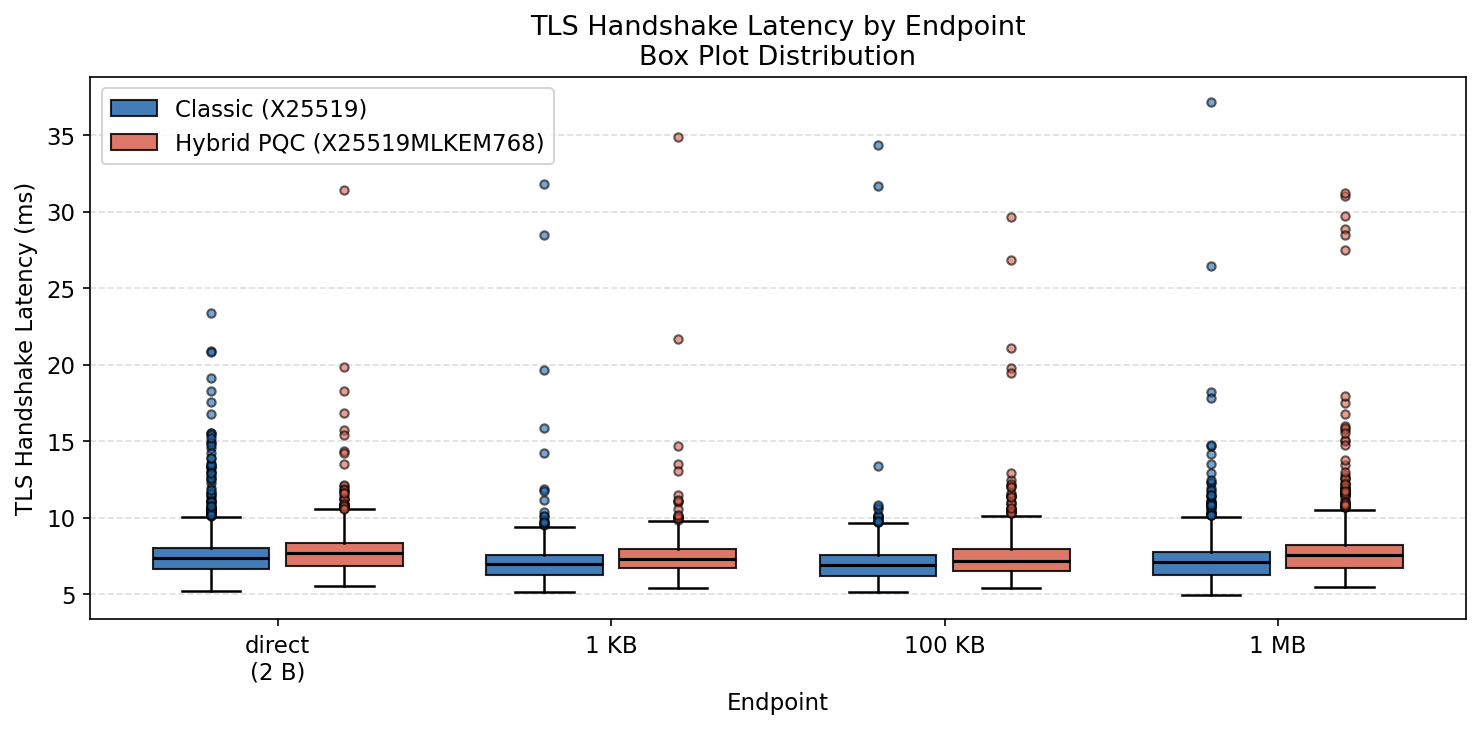

Saved fig1


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(ENDPOINT_ORDER))
offset = 0.2

classic_data = []
hybrid_data = []

for ep in ENDPOINT_ORDER:
    classic_vals = df[
        (df['endpoint'] == ep) & (df['variant'] == 'classic')
    ]['tls_handshake_ms'].dropna().values
    hybrid_vals = df[
        (df['endpoint'] == ep) & (df['variant'] == 'hybrid')
    ]['tls_handshake_ms'].dropna().values

    classic_data.append(classic_vals)
    hybrid_data.append(hybrid_vals)

bp1 = ax.boxplot(
    classic_data,
    positions=x - offset,
    widths=0.35,
    patch_artist=True,
    manage_ticks=False,
    boxprops=dict(facecolor=CLASSIC_COLOR, alpha=ALPHA, color='black'),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    flierprops=dict(marker='o', markersize=4, markerfacecolor=CLASSIC_COLOR,
                    markeredgecolor='black', alpha=0.6)
)

bp2 = ax.boxplot(
    hybrid_data,
    positions=x + offset,
    widths=0.35,
    patch_artist=True,
    manage_ticks=False,
    boxprops=dict(facecolor=HYBRID_COLOR, alpha=ALPHA, color='black'),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.2),
    capprops=dict(color='black', linewidth=1.2),
    flierprops=dict(marker='o', markersize=4, markerfacecolor=HYBRID_COLOR,
                    markeredgecolor='black', alpha=0.6)
)

ax.set_xlabel('Endpoint')
ax.set_ylabel('TLS Handshake Latency (ms)')
ax.set_title('TLS Handshake Latency by Endpoint\nBox Plot Distribution')
ax.set_xticks(x)
ax.set_xticklabels([ENDPOINT_LABELS[ep] for ep in ENDPOINT_ORDER])

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=CLASSIC_COLOR, alpha=ALPHA, edgecolor='black'),
    plt.Rectangle((0, 0), 1, 1, facecolor=HYBRID_COLOR, alpha=ALPHA, edgecolor='black'),
]
ax.legend(legend_handles, ['Classic (X25519)', 'Hybrid PQC (X25519MLKEM768)'])

ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig1_handshake_mean.pdf')
plt.show()
print('Saved fig1')

## TLS Handshake Latency Percentiles by Endpoint

This figure compares **p50**, **p95**, and **p99** TLS handshake latency across endpoints for the **Classic** and **Hybrid PQC** variants.  

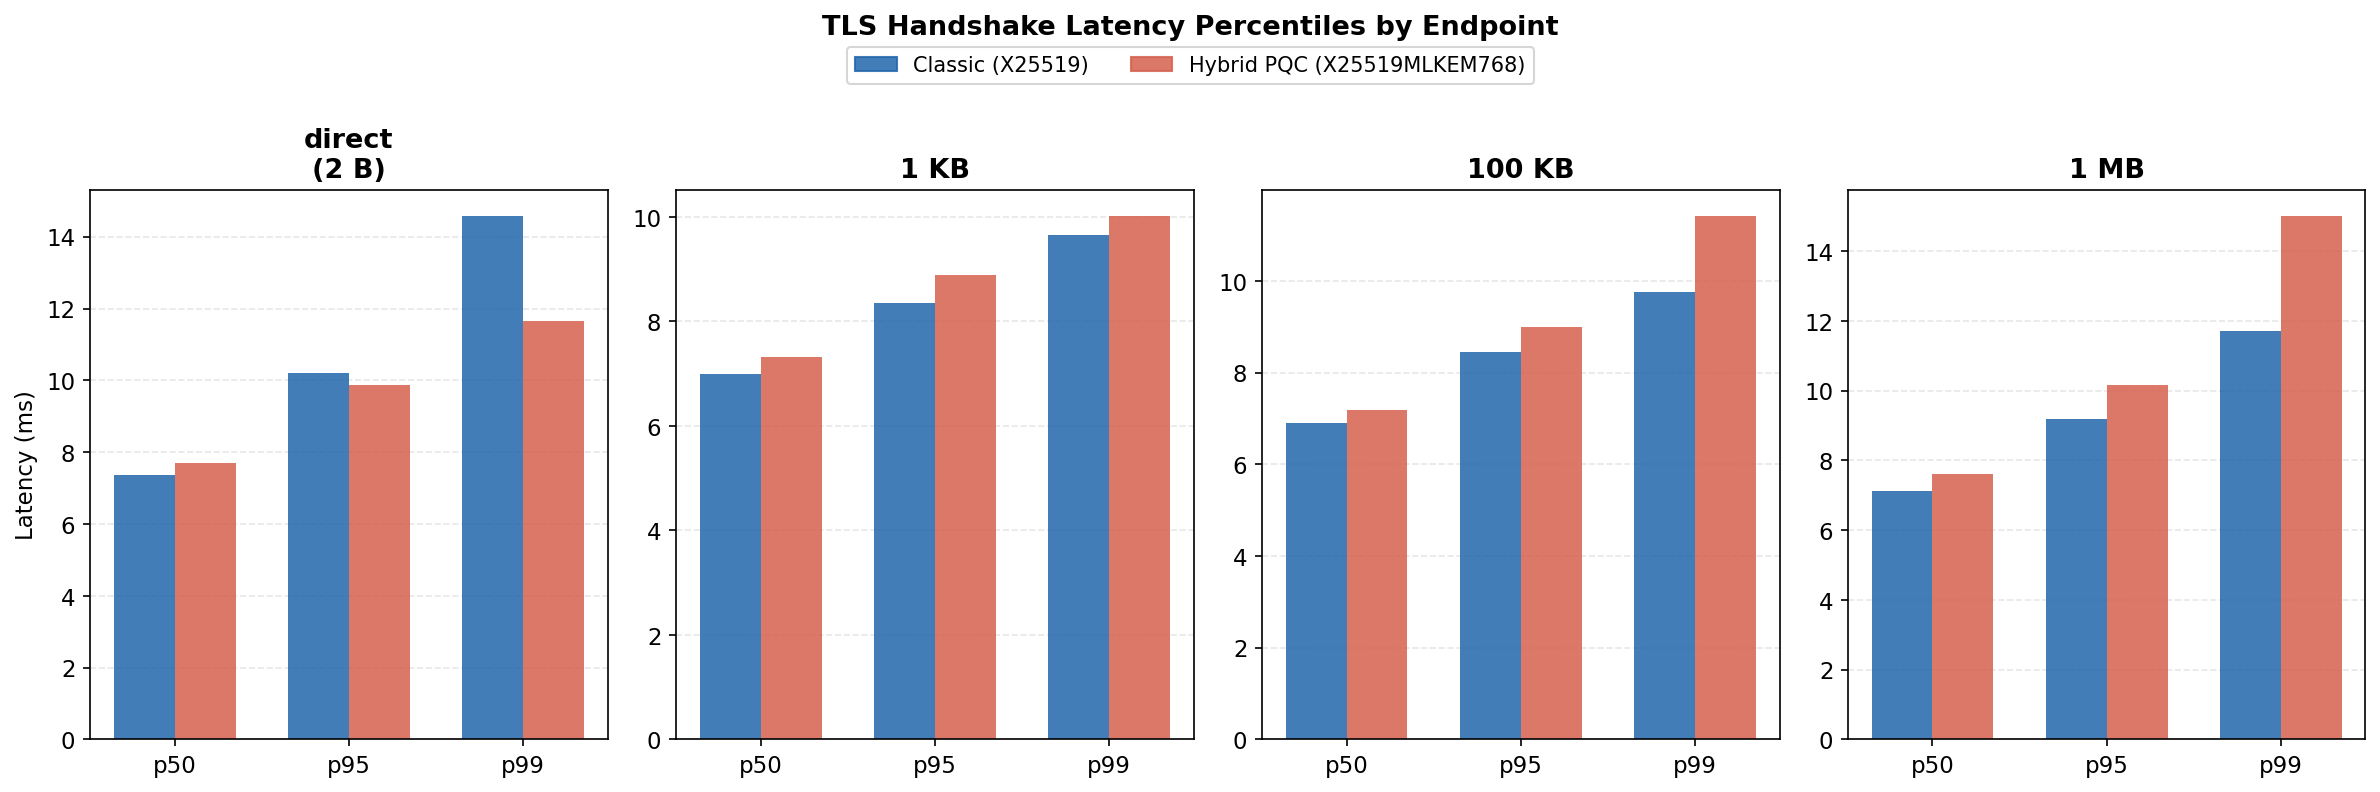

Saved fig2


In [5]:
n_ep = len(ENDPOINT_ORDER)
fig, axes = plt.subplots(1, n_ep, figsize=(4 * n_ep, 5), sharey=False)

percentiles = [50, 95, 99]
xp = np.arange(len(percentiles))
w = 0.35

for ax, ep in zip(axes, ENDPOINT_ORDER):
    for i, (variant, color, label) in enumerate([
        ('classic', CLASSIC_COLOR, 'Classic'),
        ('hybrid',  HYBRID_COLOR,  'Hybrid PQC'),
    ]):
        vals = df[(df['endpoint'] == ep) & (df['variant'] == variant)]['tls_handshake_ms']
        pvals = [vals.quantile(p / 100) for p in percentiles]
        ax.bar(xp + (i - 0.5) * w, pvals, w,
               color=color, alpha=ALPHA, label=label)

    ax.set_title(ENDPOINT_LABELS[ep], fontweight='bold')
    ax.set_xticks(xp)
    ax.set_xticklabels(['p50', 'p95', 'p99'])
    ax.set_ylabel('Latency (ms)' if ax == axes[0] else '')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_axisbelow(True)

handles = [
    mpatches.Patch(color=CLASSIC_COLOR, alpha=ALPHA, label='Classic (X25519)'),
    mpatches.Patch(color=HYBRID_COLOR,  alpha=ALPHA, label='Hybrid PQC (X25519MLKEM768)'),
]
fig.legend(handles=handles, loc='upper center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('TLS Handshake Latency Percentiles by Endpoint',
             fontsize=13, fontweight='bold', y=1.05)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig2_percentiles.pdf')
plt.show()
print('Saved fig2')

## Total Request Latency by Endpoint

This figure compares the mean **end-to-end request latency** across endpoints for the **Classic (X25519)** and **Hybrid PQC (X25519MLKEM768)** variants.  

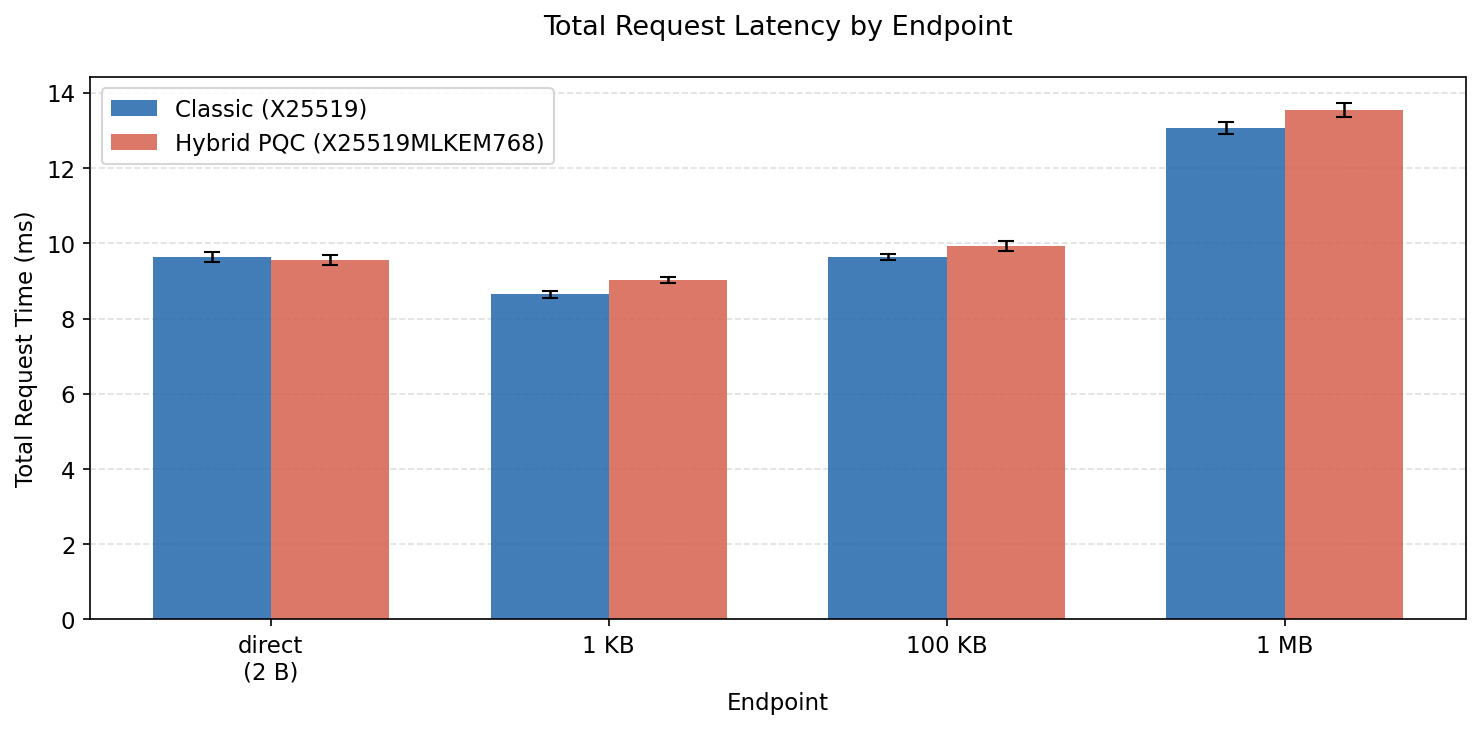

Saved fig3


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, (variant, color, label) in enumerate([
    ('classic', CLASSIC_COLOR, 'Classic (X25519)'),
    ('hybrid',  HYBRID_COLOR,  'Hybrid PQC (X25519MLKEM768)'),
]):
    means  = []
    errors = []
    for ep in ENDPOINT_ORDER:
        vals = df[(df['endpoint'] == ep) & (df['variant'] == variant)]['total_ms']
        means.append(vals.mean())
        errors.append(ci95_half(vals))

    offset = (i - 0.5) * width
    ax.bar(x + offset, means, width, yerr=errors, capsize=4,
           color=color, alpha=ALPHA, label=label,
           error_kw={'elinewidth': 1.2, 'ecolor': 'black'})

ax.set_xlabel('Endpoint')
ax.set_ylabel('Total Request Time (ms)')
ax.set_title('Total Request Latency by Endpoint\n')
ax.set_xticks(x)
ax.set_xticklabels([ENDPOINT_LABELS[ep] for ep in ENDPOINT_ORDER])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig3_total_time.pdf')
plt.show()
print('Saved fig3')

## Per-Layer Latency Decomposition from Wireshark Traces
This analysis decomposes end-to-end request processing into protocol-layer timing components derived from Wireshark packet captures.  
The measured stages include **TCP Handshake**, **TCP→TLS Delay**, **TLS Handshake**, **TLS→Application Delay**, and **Application Response**.  
For each layer, the figure compares the **Classic (X25519)** and **Hybrid PQC (X25519MLKEM768)** variants using mean latency and standard deviation, making it possible to localize where additional overhead is introduced in the protocol stack.

Classic: 200 connections
Hybrid:  200 connections

=== Overhead Summary (all layers) ===
Layer              Classic med Hybrid med  Med Diff
----------------------------------------------------------------------
TCP Handshake            0.919      0.929     +1.2%
TCP→TLS Delay            3.042      3.524    +15.8%
TLS Handshake            3.848      4.389    +14.1%
TLS→App Delay            0.124      0.136     +9.7%
App Response             0.564      0.635    +12.6%


=== TLS Handshake Layer — Detailed ===
   Variant     Mean   Median      p90      p95      p99       SD
------------------------------------------------------------
   Classic    3.877    3.848    4.484    4.637    5.103    0.454
    Hybrid    5.376    4.389    7.014   10.656   22.070    3.551


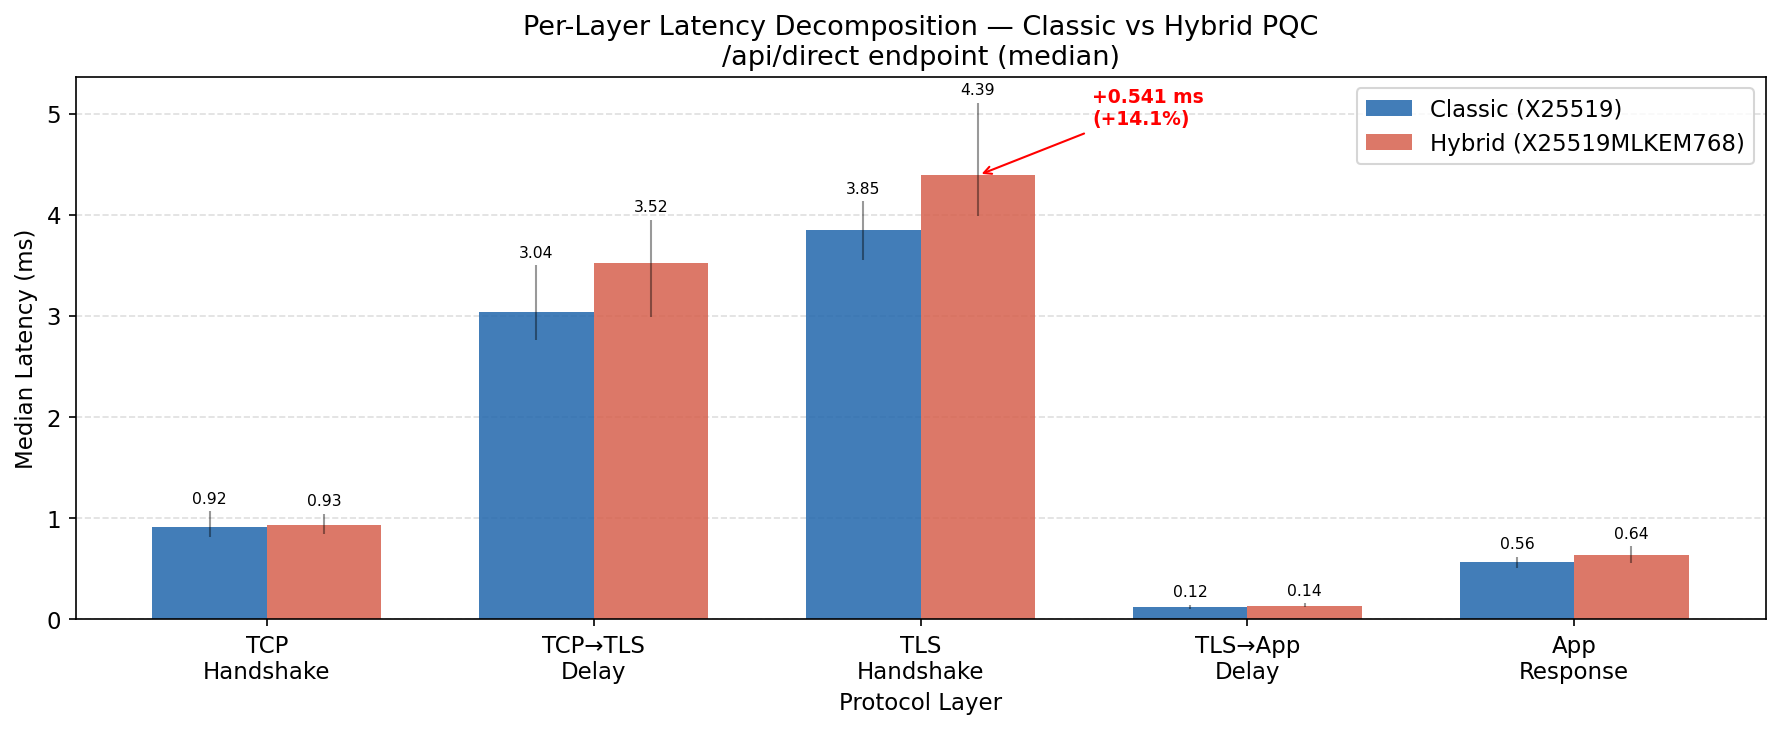

Saved fig4


In [7]:
classic_df = pd.read_csv('results/layered_analysis/classic_layered.csv')
hybrid_df  = pd.read_csv('results/layered_analysis/hybrid_layered.csv')

layer_keys   = ['tcp_hs', 'tcp_tls', 'tls_hs', 'tls_app', 'app_resp']
layer_labels = ['TCP Handshake', 'TCP→TLS Delay', 'TLS Handshake',
                'TLS→App Delay', 'App Response']

print(f'Classic: {len(classic_df)} connections')
print(f'Hybrid:  {len(hybrid_df)} connections\n')

print('=== Overhead Summary (all layers) ===')
print(f"{'Layer':18} {'Classic med':>11} {'Hybrid med':>10} "
      f"{'Med Diff':>9}")
print('-' * 70)
for l, lbl in zip(layer_keys, layer_labels):
    cm = classic_df[l].median()
    hm = hybrid_df[l].median()
    c95 = classic_df[l].quantile(0.95)
    h95 = hybrid_df[l].quantile(0.95)
    med_pct = (hm - cm) / cm * 100 if cm > 0 else 0
    p95_pct = (h95 - c95) / c95 * 100 if c95 > 0 else 0
    print(f"{lbl:18} {cm:>11.3f} {hm:>10.3f} "
          f"{med_pct:>+8.1f}%")

print('\n\n=== TLS Handshake Layer — Detailed ===')
print(f"{'Variant':>10} {'Mean':>8} {'Median':>8} {'p90':>8} "
      f"{'p95':>8} {'p99':>8} {'SD':>8}")
print('-' * 60)
for variant, df_v in [('Classic', classic_df), ('Hybrid', hybrid_df)]:
    s = df_v['tls_hs']
    print(f"{variant:>10} {s.mean():>8.3f} {s.median():>8.3f} "
          f"{s.quantile(0.90):>8.3f} {s.quantile(0.95):>8.3f} "
          f"{s.quantile(0.99):>8.3f} {s.std():>8.3f}")

medians, p25s, p75s = {}, {}, {}
for v, df_v in {'classic': classic_df, 'hybrid': hybrid_df}.items():
    medians[v] = {l: df_v[l].median()       for l in layer_keys}
    p25s[v]    = {l: df_v[l].quantile(0.25) for l in layer_keys}
    p75s[v]    = {l: df_v[l].quantile(0.75) for l in layer_keys}

fig, ax = plt.subplots(figsize=(12, 5))
xl = np.arange(len(layer_keys))
w  = 0.35

for i, (variant, color, label) in enumerate([
    ('classic', CLASSIC_COLOR, 'Classic (X25519)'),
    ('hybrid',  HYBRID_COLOR,  'Hybrid (X25519MLKEM768)'),
]):
    vals = [medians[variant][l] for l in layer_keys]
    lower = [medians[variant][l] - p25s[variant][l] for l in layer_keys]
    upper = [p75s[variant][l]    - medians[variant][l] for l in layer_keys]
    errs = [lower, upper]
    offset = (i - 0.5) * w
    bars = ax.bar(xl + offset, vals, w,
                  color=color, alpha=ALPHA, label=label,
                  yerr=errs, capsize=0,
                  error_kw=dict(elinewidth=1, ecolor='black', alpha=0.4))
    for bar, val, up in zip(bars, vals, upper):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + up + 0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)

tls_idx = 2
cm_tls = medians['classic']['tls_hs']
hm_tls = medians['hybrid']['tls_hs']
ax.annotate(
    f"+{hm_tls - cm_tls:.3f} ms\n({(hm_tls - cm_tls) / cm_tls * 100:+.1f}%)",
    xy=(xl[tls_idx] + w/2, hm_tls),
    xytext=(xl[tls_idx] + w/2 + 0.35, hm_tls + 0.5),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=9, color='red', fontweight='bold'
)

ax.set_xlabel('Protocol Layer')
ax.set_ylabel('Median Latency (ms)')
ax.set_title('Per-Layer Latency Decomposition — Classic vs Hybrid PQC\n'
             '/api/direct endpoint (median)')
ax.set_xticks(xl)
ax.set_xticklabels([l.replace(' ', '\n', 1) for l in layer_labels])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4_wireshark_layers.pdf', bbox_inches='tight')
plt.show()
print('Saved fig4')

# Raw Handshake Throughput
Using `openssl s_time` we benchmark TLS connection

In [8]:
stime_files = sorted(glob.glob('results/stime/stime_*.csv'))
assert stime_files, "No s_time CSV files found in results/stime/"
print(f'Found {len(stime_files)} s_time file(s)')

stime_df = pd.concat([pd.read_csv(f) for f in stime_files], ignore_index=True)
print(f'Total rows: {len(stime_df)}\n')

summary = stime_df.groupby('variant')['conn_per_sec'].agg(
    mean='mean',
    std='std',
    min='min',
    max='max',
).round(2)

classic_mean = summary.loc['classic', 'mean']
hybrid_mean  = summary.loc['hybrid', 'mean']
overhead_pct = (hybrid_mean - classic_mean) / classic_mean * 100

print('TLS Handshake Throughput Summary (conn/s)')
print('=' * 60)
print(summary.to_string())
print()
print(f'Classic:  {classic_mean:.1f} ± {summary.loc["classic", "std"]:.1f} conn/s')
print(f'Hybrid:   {hybrid_mean:.1f} ± {summary.loc["hybrid", "std"]:.1f} conn/s')
print(f'Overhead: {overhead_pct:+.1f}%')

Found 1 s_time file(s)
Total rows: 20

TLS Handshake Throughput Summary (conn/s)
           mean    std     min     max
variant                               
classic  256.40  10.81  236.84  273.03
hybrid   238.91   9.99  223.62  259.61

Classic:  256.4 ± 10.8 conn/s
Hybrid:   238.9 ± 10.0 conn/s
Overhead: -6.8%
